# Advanced Classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"..\..\Dataset\dataset_module_one_DM2.csv")
df.shape

(7700, 37)

In [3]:
X = df.drop(columns=['sii']).values
y = np.array(df['sii'].values)

print(X.shape)
print(y.shape)

(7700, 36)
(7700,)


## Data Partitioning

In [4]:
from sklearn.model_selection import train_test_split, cross_val_score 

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
scl = StandardScaler()
X_train = scl.fit_transform(X_train)
X_test = scl.transform(X_test)

## Logistic Regression

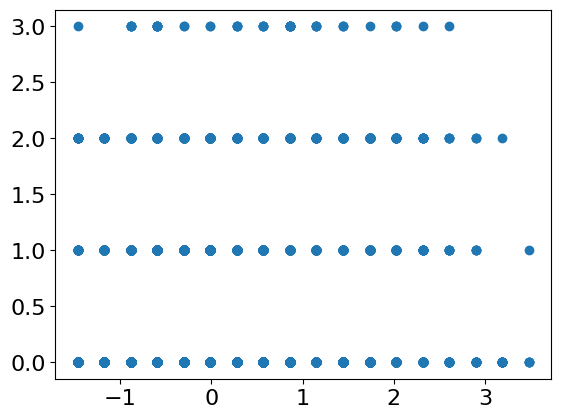

In [8]:
plt.scatter(X_train.T[0], y_train)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.show()

In [9]:
df['sii'].value_counts()

sii
0.0    5400
1.0    1437
2.0     796
3.0      67
Name: count, dtype: int64

In [10]:
pd.DataFrame(y_train).value_counts()

0  
0.0    3780
1.0    1006
2.0     557
3.0      47
Name: count, dtype: int64

In [11]:
# OVERSAMPLING THE MINORITY CLASSES USING SMOTE

from imblearn.over_sampling import SMOTE

# Initialize SMOTE with a custom sampling strategy to prevent overfitting
# This tells SMOTE exactly how many samples to generate for each class.
custom_strategy = {
    1.0: 2000,
    2.0: 2000,
    3.0: 1000
}

smote = SMOTE(sampling_strategy=custom_strategy, random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [13]:
clf = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
# clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_resampled, y_train_resampled)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...ndom_state=42)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=

In [14]:
y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.46320346320346323
F1-score [0.66371027 0.1779661  0.29241379 0.01247401]
              precision    recall  f1-score   support

         0.0       0.83      0.55      0.66      1620
         1.0       0.23      0.15      0.18       431
         2.0       0.22      0.44      0.29       239
         3.0       0.01      0.15      0.01        20

    accuracy                           0.46      2310
   macro avg       0.32      0.32      0.29      2310
weighted avg       0.64      0.46      0.53      2310



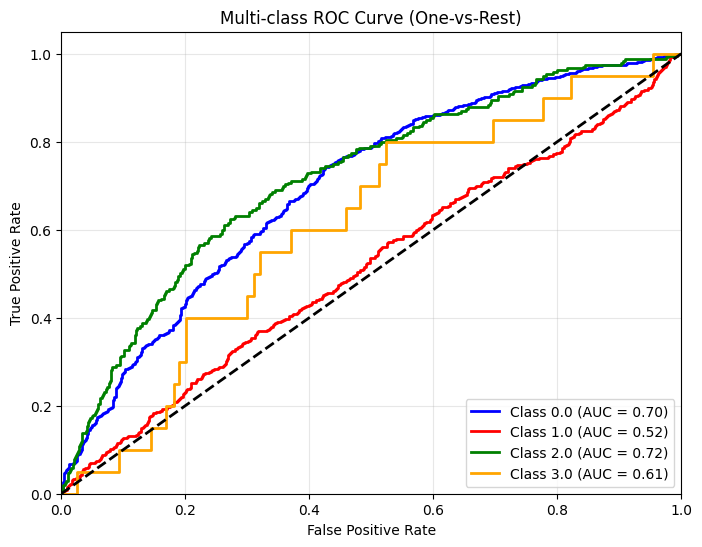

In [15]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Binarize target labels for multi-class ROC
classes = [0.0, 1.0, 2.0, 3.0]
y_test_bin = label_binarize(y_test, classes=classes)

# Get prediction probabilities
y_score = clf.predict_proba(X_test)

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange']

for i, color in enumerate(colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, 
             label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

# Plot random guessing baseline
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [16]:
# Loop through each fitted LogisticRegression model
for i, model in enumerate(clf.estimators_):
    
    class_label = clf.classes_[i]
    
    # Extract the weights and bias
    # Note: .coef_ returns a 2D array of shape (1, n_features), so we grab index [0]
    weights = model.coef_[0] 
    bias = model.intercept_[0]
    
    print(f"--- Model for Class: {class_label} ---")
    print(f"Weights: {weights}")
    print(f"Intercept: {bias}\n")

--- Model for Class: 0.0 ---
Weights: [-0.01693829  0.21028477  0.01222811 -0.0436908   0.17282417 -0.06036345
  0.02970399 -0.00593939 -0.02318549  0.00469358 -0.08845536  0.02724625
 -0.02922082  0.15765137 -0.07404206 -0.09025723  0.02044303  0.03904802
  0.03236997  0.40791758 -0.00310927 -0.084252   -0.00363239 -0.87692968
  0.00542508 -0.08294909  0.04429337 -0.13007557  0.08985994 -0.0055152
 -0.45585628 -0.29000805 -0.21256314  0.25983028 -0.05255365 -0.0552457 ]
Intercept: 0.12408563805352367

--- Model for Class: 1.0 ---
Weights: [ 6.81281612e-02  5.14022691e-02  5.34626638e-02  8.03133397e-02
 -5.86201545e-02  1.67180286e-01 -7.50975564e-02  3.03857577e-02
  1.24289566e-01 -1.97549542e-02  6.38349528e-02  6.08303046e-03
 -1.16351685e-01 -6.60622192e-02  3.44201340e-02  1.87508742e-01
 -5.00215761e-03 -2.76959398e-03 -6.16827755e-01 -2.53823121e-01
  1.16524098e-01  1.38386013e-02 -9.60730175e-02  1.86525405e-02
  3.72994825e-02 -3.07186798e-02 -5.93148715e-02  2.92530700e-01

### Note
- Logistic Regression is a linear model. It tries to draw straight lines (or flat planes) through our data to separate the classes. If Class 1 or Class 3 is scattered wildly amongst Class 0, a straight line will never be able to separate them, no matter how much we resample the data.

- SMOTE is undeniably working better than the class_weight approach, but we have hit the ceiling of what Logistic Regression can do with our current features.